In [3]:
%load_ext autoreload
%autoreload 2

In [9]:
from runner import ALGORITHMS, get_crossing_function
from runner import algo_fr, algo_kk, algo_smartgd, algo_rlgc, algo_oldrl, algo_rllc, algo_edgeins, algo_upwards, algo_vermove, algo_sgd2
import gdMetriX

algo_labels   = {
    "smartgd": "SmartGD",
    "edgeins": "EI",
    "vermove": "VM",
    "fr":      "FR",
    "kk":      "KK",
    "sgd2":    "(SGD)²",
    "rlgc":    "RL(GC)",
    "rllc":    "RL(LC)",
    "upwards": "TB",
    "oldrl" :  "OLDRL",
}

In [5]:
from pathlib import Path
from typing import Iterable, Mapping
import networkx as nx
import matplotlib.pyplot as plt
from IPython.display import display
print("cwd =", Path().resolve())


cwd = /storage/home/brand/RLGD/SmartGD/runner


In [4]:
# --- choose which algorithms you want to see -------------------------
SLECTED_ALGOS = [
                 'rlgc',
                 'rllc',
                 'sgd2',
                 'smartgd',
                 'edgeins',
                 'vermove',
                 'upwards',
                 'kk',
                 'fr',
                 # 'oldrl'
                 ]
ORDER = ['RL(GC)', 'RL(LC)', '(SGD)²', 'SmartGD', 'EI', 'VM', 'TB', 'KK', 'FR']


ALGOS_TO_SHOW: Mapping[str, callable] = {
    k: v for k, v in ALGORITHMS.items()
    if k in SLECTED_ALGOS
}
from collections import OrderedDict
ALGOS_TO_SHOW = OrderedDict(
    (k, ALGOS_TO_SHOW[k]) for k in SLECTED_ALGOS if k in ALGOS_TO_SHOW
)
print(ALGOS_TO_SHOW)

OrderedDict([('rlgc', <function algo_rlgc at 0x7fb60f379da0>), ('rllc', <function algo_rllc at 0x7fb60f379e40>), ('sgd2', <function algo_sgd2 at 0x7fb60f37a0c0>), ('smartgd', <function algo_smartgd at 0x7fb60f379d00>), ('edgeins', <function algo_edgeins at 0x7fb60f379ee0>), ('vermove', <function algo_vermove at 0x7fb60f379f80>), ('upwards', <function algo_upwards at 0x7fb60f37a020>), ('kk', <function algo_kk at 0x7fb60f379c60>), ('fr', <function algo_fr at 0x7fb60f379bc0>)])


In [35]:
cache = {}

In [49]:
def plot_layout_grid(graph_files: Path | Iterable[Path],
                     algos: Mapping[str, callable] = ALGOS_TO_SHOW,
                     time_limit: float = 600,
                     cache: dict | None = None,
                     swap: bool = False):
    """
    Draws a grid of layouts. By default each row is one graph and each column
    is one algorithm. If swap=True, rows <-> columns are flipped.
    """
    if isinstance(graph_files, (str, Path)):
        graph_files = [Path(graph_files)]
    cache = {} if cache is None else cache

    graph_files = list(graph_files)
    algo_names  = list(algos.keys())

    # decide grid shape
    if not swap:
        n_rows, n_cols = len(graph_files), len(algo_names)
    else:
        n_rows, n_cols = len(algo_names),  len(graph_files)

    fig, axes = plt.subplots(n_rows, n_cols,
                             figsize=(3.2*n_cols, 2.8*n_rows),
                             squeeze=False)

    def _draw(ax, G, pos):
        nx.draw_networkx_edges(G, pos, ax=ax, width=.8, alpha=.6)
        nx.draw_networkx_nodes(G, pos, ax=ax,
                               node_size=30, linewidths=.2, edgecolors="k")
        ax.set_xticks([]); ax.set_yticks([])

    for i in range(n_rows):
        for j in range(n_cols):
            # pick graph & algo depending on swap
            if not swap:
                g_path   = graph_files[i]
                algo_key = algo_names[j]
            else:
                g_path   = graph_files[j]
                algo_key = algo_names[i]

            fn = algos[algo_key]
            key = (g_path, algo_key)

            G = (nx.read_gml(g_path) if g_path.suffix==".gml"
                 else nx.read_gexf(g_path)).to_undirected()
            G = nx.convert_node_labels_to_integers(G)

            # load / compute
            if key in cache:
                pos, elapsed = cache[key]
            else:
                try:
                    pos, elapsed = fn(G, time_limit=time_limit,
                                      graph_path=g_path)
                except Exception as e:
                    print(f"[WARN] {algo_key} failed on {g_path.name}: {e}")
                    pos, elapsed = nx.spring_layout(G, seed=42), None
                cache[key] = (pos, elapsed)

            ax = axes[i][j]
            # shrink axes to make room for text
            box = ax.get_position()
            ax.set_position([
                box.x0,
                box.y0 + 0.05*box.height,
                box.width*0.95,
                box.height*0.95
            ])

            # column titles
            if i == 0:
                if not swap:
                    ax.set_title(algo_labels[algo_key],
                                 fontsize=14, pad=10)
                else:
                    n, m = G.number_of_nodes(), G.number_of_edges()
                    label = f"{g_path.stem}\n|V|={n}, |E|={m}"
                    ax.set_title(label,
                                 fontsize=14, pad=10)

            # row labels
            if j == 0:
                if not swap:
                     n, m = G.number_of_nodes(), G.number_of_edges()
                     label = f"{g_path.stem}\n|V|={n}, |E|={m}"
                     rotation = 0
                     ha = "right"
                else:
                    label = f"{algo_labels[algo_key]}"
                    rotation = 90
                    ha = "center"
                ax.set_ylabel(label,
                              rotation=rotation, ha=ha, va="center",
                              fontsize=14, labelpad=10)



            # annotate crossings + time
            txt = []
            if elapsed is None:
                # draw
                _draw(ax, nx.Graph(), cache[key][0])
                txt = ["timeout"]
            else:
                # draw
                _draw(ax, G, cache[key][0])
                gcn, lcn = get_crossing_function(G, cache[key][0], "")
                txt = [f"GCN={gcn}", f"LCN={lcn}", f"{cache[key][1]:.2f}s"]

            ax.text(0.98, 0.02, "  ".join(txt),
                    transform=ax.transAxes,
                    ha="right", va="bottom",
                    fontsize=10, color="0.15",
                    bbox=dict(boxstyle="round,pad=0.2",
                              fc="w", ec="0.8", lw=.5, alpha=.9))

    plt.tight_layout()
    plt.savefig(f"figures/grid_drawings_{n_rows}_by_{n_cols}.pdf")
    plt.show()
    return cache

In [37]:
# one graph
# plot_layout_grid(Path("temp_BA/ba_02_n54_m2.gml"))
# plot_layout_grid(Path("../../sng/graphs/rome_filtered/splits/data/grafo10089.37.gml"))

In [38]:
# del cache[(graphs[-1], "edgeins")]
# print(cache.keys())

 1 1
 11 3
 149 9
 1 1
 4 1
 2 1
 9 3
 149 10
 2 1
 4 2
 0 0
 8 2
 38 4
 4 3
 11 3
 3 1
 6 2
 54 5
 2 1
 4 2
 1 1
 4 2
 83 8
 1 1
 1 1
 1 1
 4 2
 90 9
 1 1
 4 1
 1 1
 11 3
 158 13
 2 1
 5 1
 3 1
 12 3
 169 15
 2 1
 10 2
 3 1
 20 4
 166 10
 8 2
 14 4


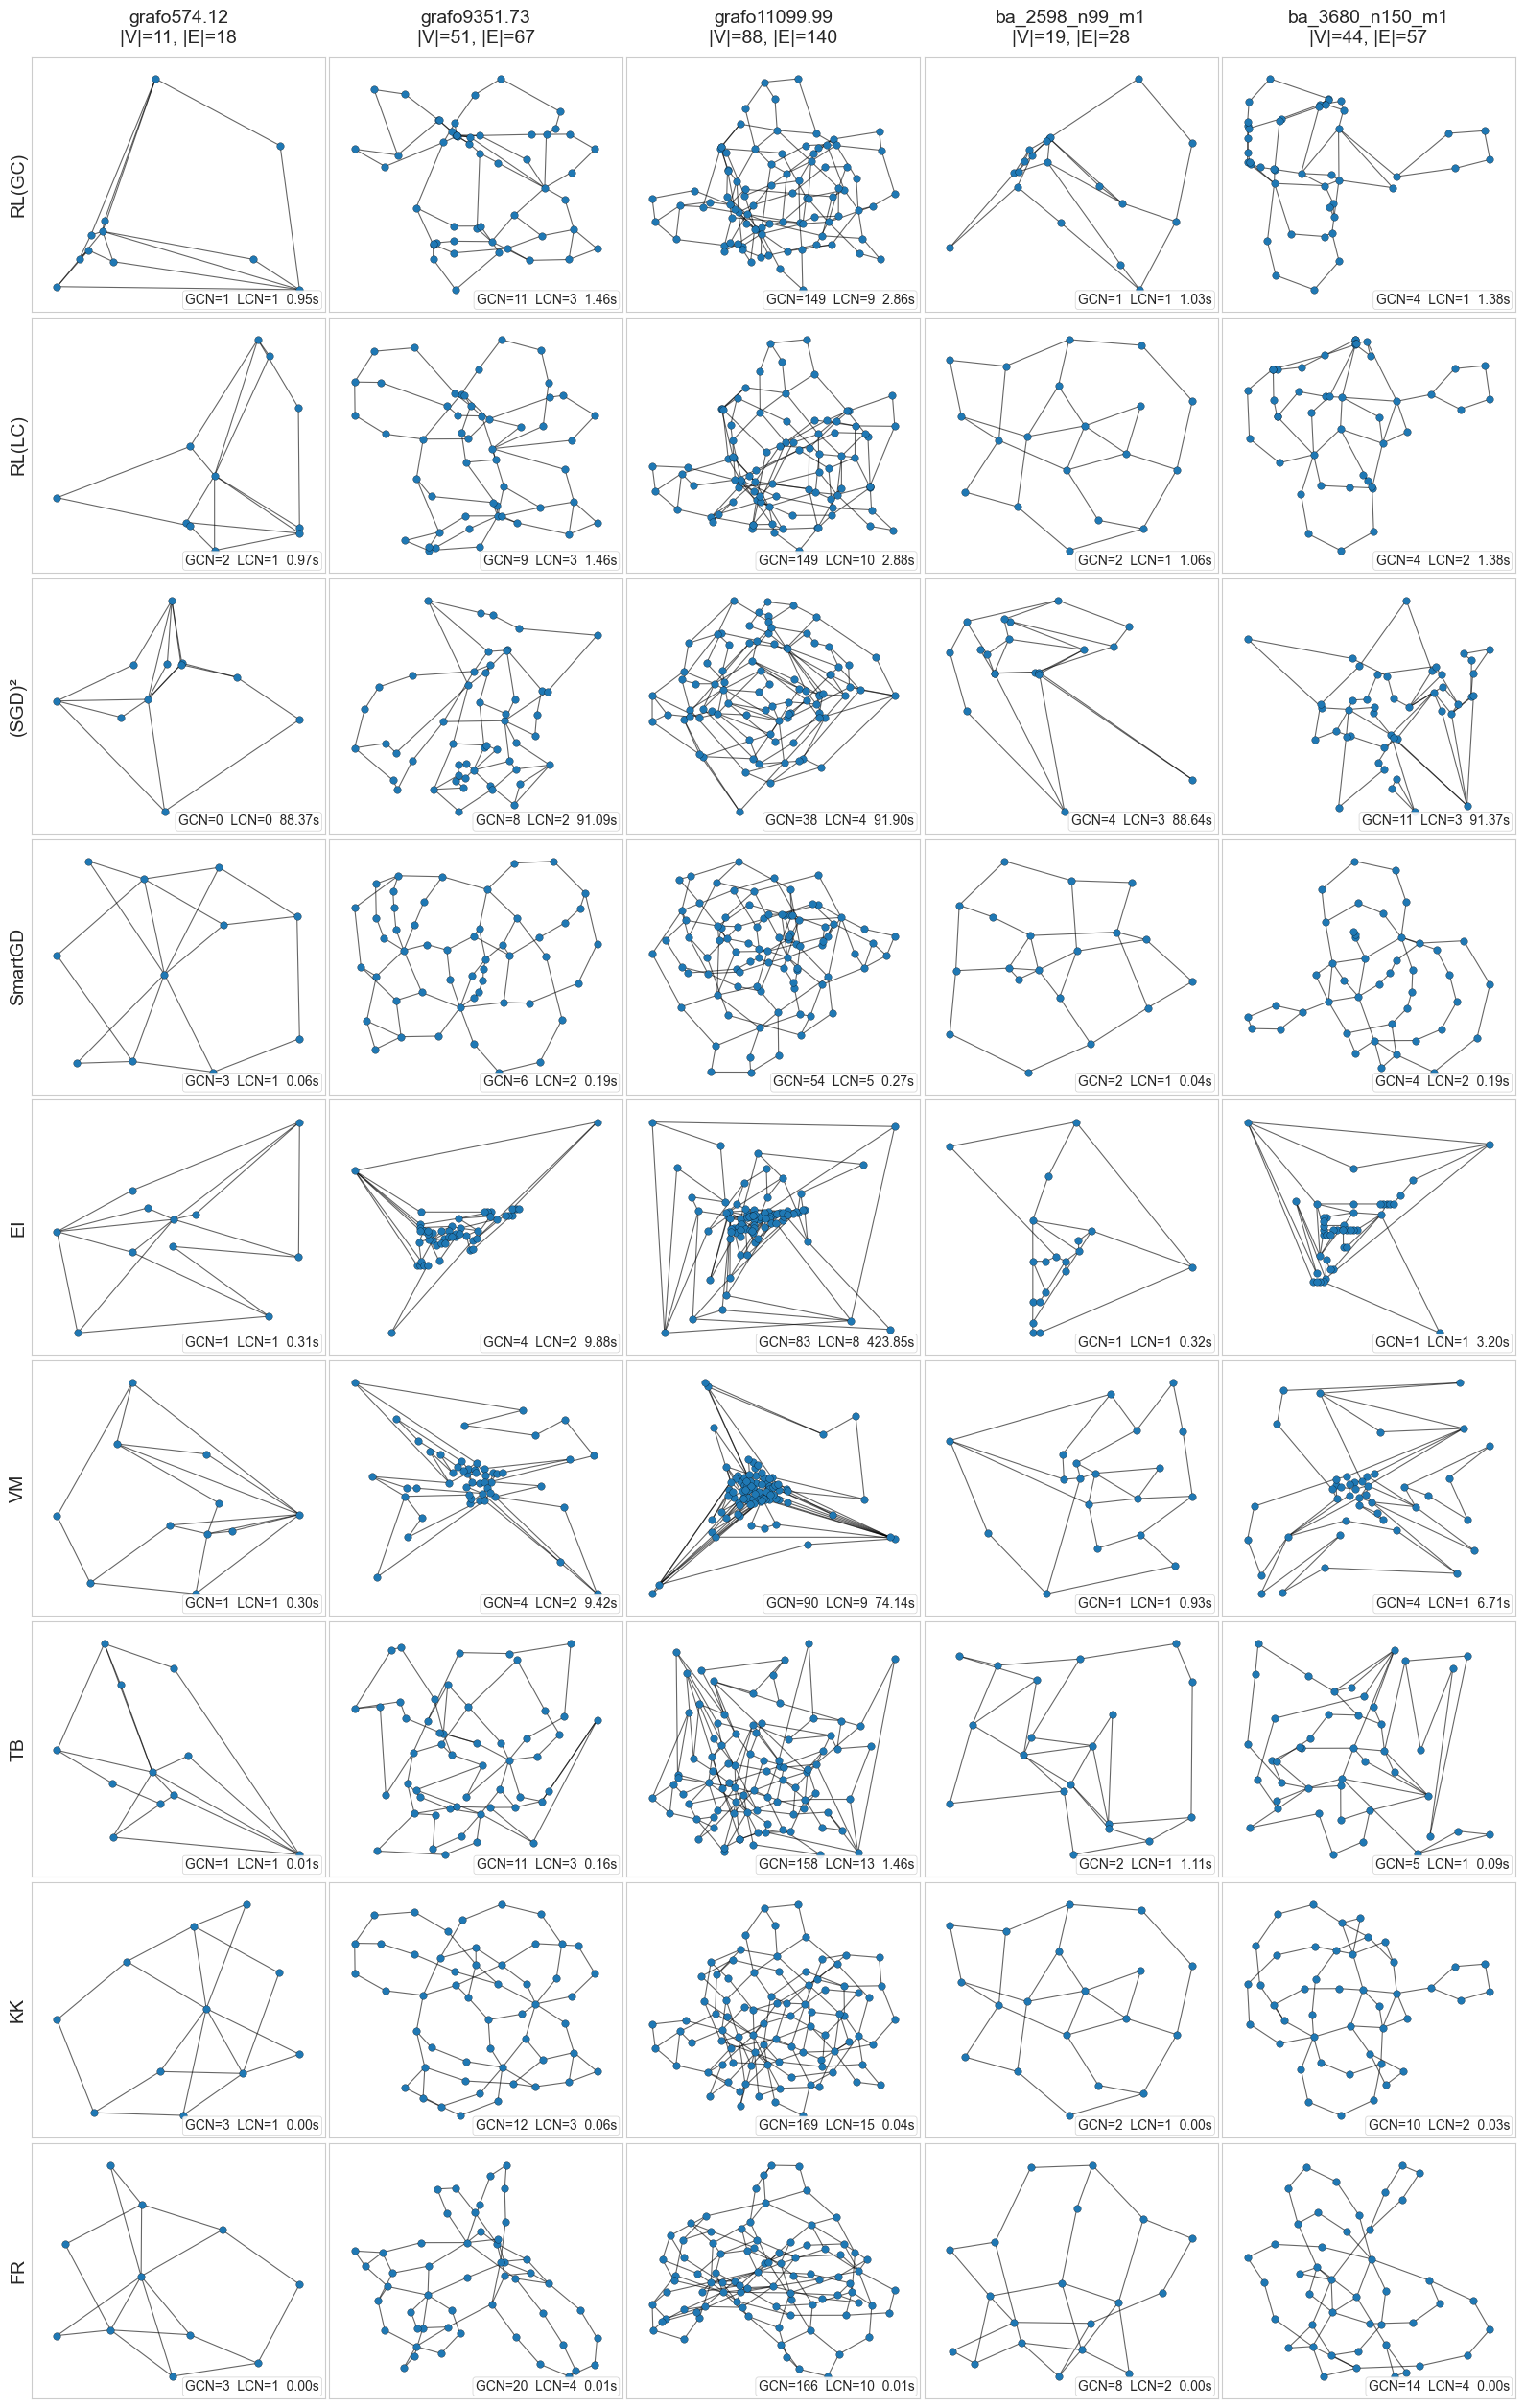

In [50]:

# several graphs
# graphs = sorted(Path("graphs/").glob("*.gml"))[:4]   # first 4

def get_path(file):
    if "grafo" in file:
        return Path("../../sng/graphs/rome_filtered/splits/data/"+file)
    elif "ba" in file:
        return Path("../../sng/graphs/extended_BA_filtered/data/"+file)
    print("Failed to find path for", file)

files = ["grafo574.12.gml",  "grafo9351.73.gml",  "grafo11099.99.gml",
         "ba_2598_n99_m1.gml",  "ba_3680_n150_m1.gml"]#,  "ba_5497_n61_m3.gml"] #"ba_8422_n70_m2.gml"]

graphs = [get_path(file) for file in files]
cache  = plot_layout_grid(graphs, cache=cache, swap=True, time_limit=900)

In [40]:

# later: plot another algorithm without recomputing the others
# ALGOS_TO_SHOW["ppo"] = ALGORITHMS["ppo"]
# plot_layout_grid(graphs, ALGOS_TO_SHOW, cache=cache)


In [41]:
import pandas as pd
from pathlib import Path
from typing import Mapping, Tuple

def generate_crossing_tables_latex(
    cache: dict[tuple[Path,str], tuple],
    graph_files: list[Path],
    algos: list[str],
    algo_labels: Mapping[str,str] | None = None,
    label_prefix: str = "crossing"
) -> Tuple[str, str]:
    """
    Builds two LaTeX tables (GCN and LCN) with:
      • rows = algorithms
      • columns = graphs
      • best (min) entry per graph bolded
      • graph names escaped for '_'
    """
    # pretty labels for the algos
    if algo_labels is None:
        algo_labels = {a:a for a in algos}

    # escaped graph names for LaTeX
    graph_names = [p.stem.replace("_","\\_") for p in graph_files]

    # collect raw numbers
    data_gcn = {g:[] for g in graph_names}
    data_lcn = {g:[] for g in graph_names}

    for alg in algos:
        for p, esc in zip(graph_files, graph_names):
            pos, elapse = cache[(p, alg)]
            gcn, lcn = get_crossing_function(nx.convert_node_labels_to_integers(nx.read_gml(p)), pos, "")
            data_gcn[esc].append(gcn)
            data_lcn[esc].append(lcn)

    # DataFrames: index=algo_labels[alg], cols=graph_names
    idx = [algo_labels[a] for a in algos]
    df_gcn = pd.DataFrame(data_gcn, index=idx)
    df_lcn = pd.DataFrame(data_lcn, index=idx)

    # helper to bold the min in each column
    def bold_min(df: pd.DataFrame) -> pd.DataFrame:
        df_str = df.astype(int).astype(str)
        mins = df.min()
        for col in df.columns:
            m = mins[col]
            df_str.loc[df[col] == m, col] = r"\textbf{" + df_str.loc[df[col]==m,col] + "}"
        return df_str

    # apply bolding
    df_gcn_b  = bold_min(df_gcn)
    df_lcn_b  = bold_min(df_lcn)

    # convert to latex
    latex_gcn = df_gcn_b.to_latex(
        na_rep="",
        escape=False,
        index=True,
        caption="Global crossing numbers",
        label=f"tab:{label_prefix}_gcn",
        column_format="l" + "r"*len(graph_names)
    )
    latex_lcn = df_lcn_b.to_latex(
        na_rep="",
        escape=False,
        index=True,
        caption="Local crossing numbers",
        label=f"tab:{label_prefix}_lcn",
        column_format="l" + "r"*len(graph_names)
    )

    return latex_gcn, latex_lcn


In [6]:
latex_gcn, latex_lcn = generate_crossing_tables_latex(
    cache, graphs, ALGOS_TO_SHOW, algo_labels=algo_labels
)

# display the LaTeX code:
print(latex_gcn)
print(latex_lcn)

NameError: name 'generate_crossing_tables_latex' is not defined

In [54]:
import ast
def short_crossings(G, pos):
    crosses1 = gdMetriX.get_crossings(G, pos=pos)
    crosses2 = gdMetriX.get_crossings_quadratic(G, pos=pos)
    total1 = len(crosses1)
    total2 = len(crosses2)
    per_e1 = {frozenset(e): 0 for e in G.edges()}
    per_e2 = {frozenset(e): 0 for e in G.edges()}
    for c in crosses1:
        cstr = str(c).split("edges: ")[-1][:-1]
        edges = ast.literal_eval(cstr)
        for (u1, v1) in edges:
            per_e1[frozenset((u1, v1))] += 1
    for c in crosses2:
        cstr = str(c).split("edges: ")[-1][:-1]
        edges = ast.literal_eval(cstr)
        for (u1, v1) in edges:
            per_e2[frozenset((u1, v1))] += 1
    lcn1 = max(per_e1.values(), default=0)
    lcn2 = max(per_e2.values(), default=0)
    return total1, lcn1, total2, lcn2

is_planar: False


  0%|          | 0/10000 [00:00<?, ?it/s]

99.1970328160096 8 2 17 6
Graph with 38 nodes and 57 edges
{'0': array([ -2.4836798, -24.19595  ], dtype=float32), '2': array([-19.524864, -27.292656], dtype=float32), '3': array([ 0.8553231, -2.6297011], dtype=float32), '4': array([4.9306436, 1.9604359], dtype=float32), '5': array([4.6259937, 2.5982993], dtype=float32), '6': array([33.55602, 39.4704 ], dtype=float32), '7': array([20.290934 , -7.8560047], dtype=float32), '8': array([ 14.332834, -31.49294 ], dtype=float32), '10': array([22.421343,  9.584693], dtype=float32), '11': array([ 5.8518376, -8.492413 ], dtype=float32), '13': array([10.995148 ,  4.0681767], dtype=float32), '14': array([  4.27869 , -11.237567], dtype=float32), '15': array([ 4.722792, -8.139854], dtype=float32), '16': array([ 5.186639, -5.689832], dtype=float32), '17': array([ 10.995144, -21.546534], dtype=float32), '18': array([20.25499  , -7.0824265], dtype=float32), '19': array([ -7.681225, -23.127558], dtype=float32), '20': array([ 7.182647 , -0.8427633], dtyp

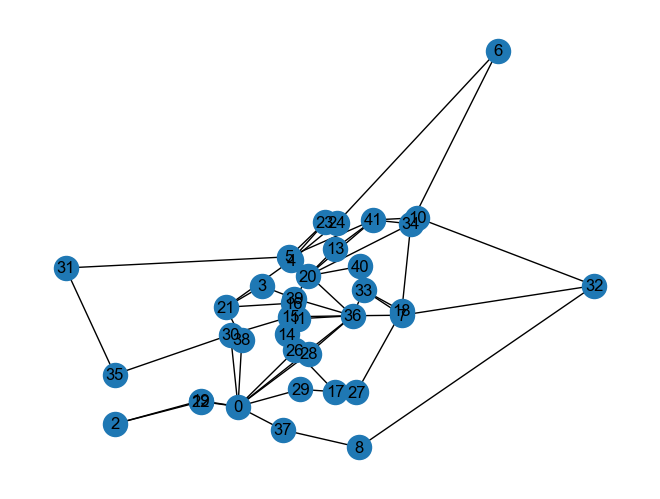

In [55]:
# G = nx.read_gml("../../sng/graphs/rome_filtered/splits/data/grafo1683.11.gml")
# G = nx.read_gml("../../sng/graphs/rome_filtered/splits/data/grafo3532.99.gml")
G = nx.read_gml("../../sng/graphs/rome_filtered/splits/data/grafo10008.42.gml")
print("is_planar:", nx.is_planar(G))

while True:
    pos, elapsed = algo_sgd2(G)
    # pos, elapsed = algo_smartgd(G)
    # pos, elapsed = algo_fr(G)
    print(elapsed, end=" ")
    total1, lcn1, total2, lcn2 = short_crossings(G,pos)
    print(total1, lcn1, total2, lcn2)
    if total1 != total2:
        nx.draw(G,pos=pos, with_labels=True)
        print(G)
        print(pos)
        fpos = pos
        break

 2 1
2


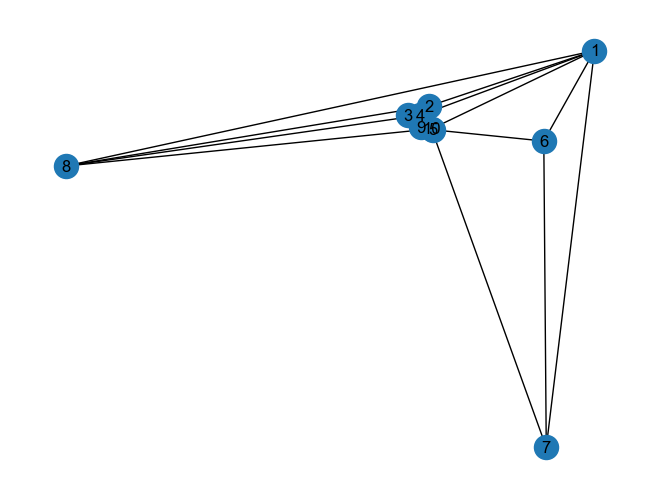

In [14]:
import gdMetriX
nx.draw(G, pos=fpos, with_labels=True)
get_crossing_function(G, fpos)
print(gdMetriX.number_of_crossings(G, fpos, use_quadratic_algorithm=True))